# Electrolyser models comparison

In [1]:
from electrolyser_detailed_model import Electrolyser as ELEC_old
from electrolyser_model import Electrolyser as ELEC_new
from electrolyser_vectorized import ElectrolyserCore as ELEC_vec

In [2]:
import matplotlib.pyplot as plt
from matplotlib import ticker
import numpy as np

In [3]:
sampling_time = 5

In [4]:
elec_old = ELEC_old(ID = 0, delta_t = sampling_time)
elec_new = ELEC_new(elec_id = 0, sampling_time = sampling_time)
elec_vec = ELEC_vec(ident=0, delta_t=sampling_time)

In [5]:
u = 0.8

out_ref = []

out_old = []
out_new = []
out_vec = []

temp_old = []
temp_new = []
temp_vec = []

steps = 1500

In [6]:
deterioration = None

In [7]:
for t in range(steps):

    if 1000 <= t < 1100:
        u = 0.6

    if 1100 <= t < 1200:
        u = 1

    if t > 1200:
        u = 0

    out_ref.append(u)

    out_old.append(elec_old.getDinamics()[0])
    out_new.append(elec_new.output)
    out_vec.append(elec_vec.dynamics[0])

    temp_old.append(elec_old.getTemperatureDinamics()[0])
    temp_new.append(elec_new.temperature)
    temp_vec.append(elec_vec.temperature)

    deterioration = elec_new.deterioration

    elec_old.apply_control_signal_in_moment(u)
    elec_new.step(u)
    elec_vec.apply_signal(u)

In [8]:
HOUR_TO_SEC = 60 * 60
NUMBER_OF_ELECTROLYSERS = 1
HOURS_IN_SIMULATION = steps * sampling_time / HOUR_TO_SEC
SAMPLING_TIME = sampling_time

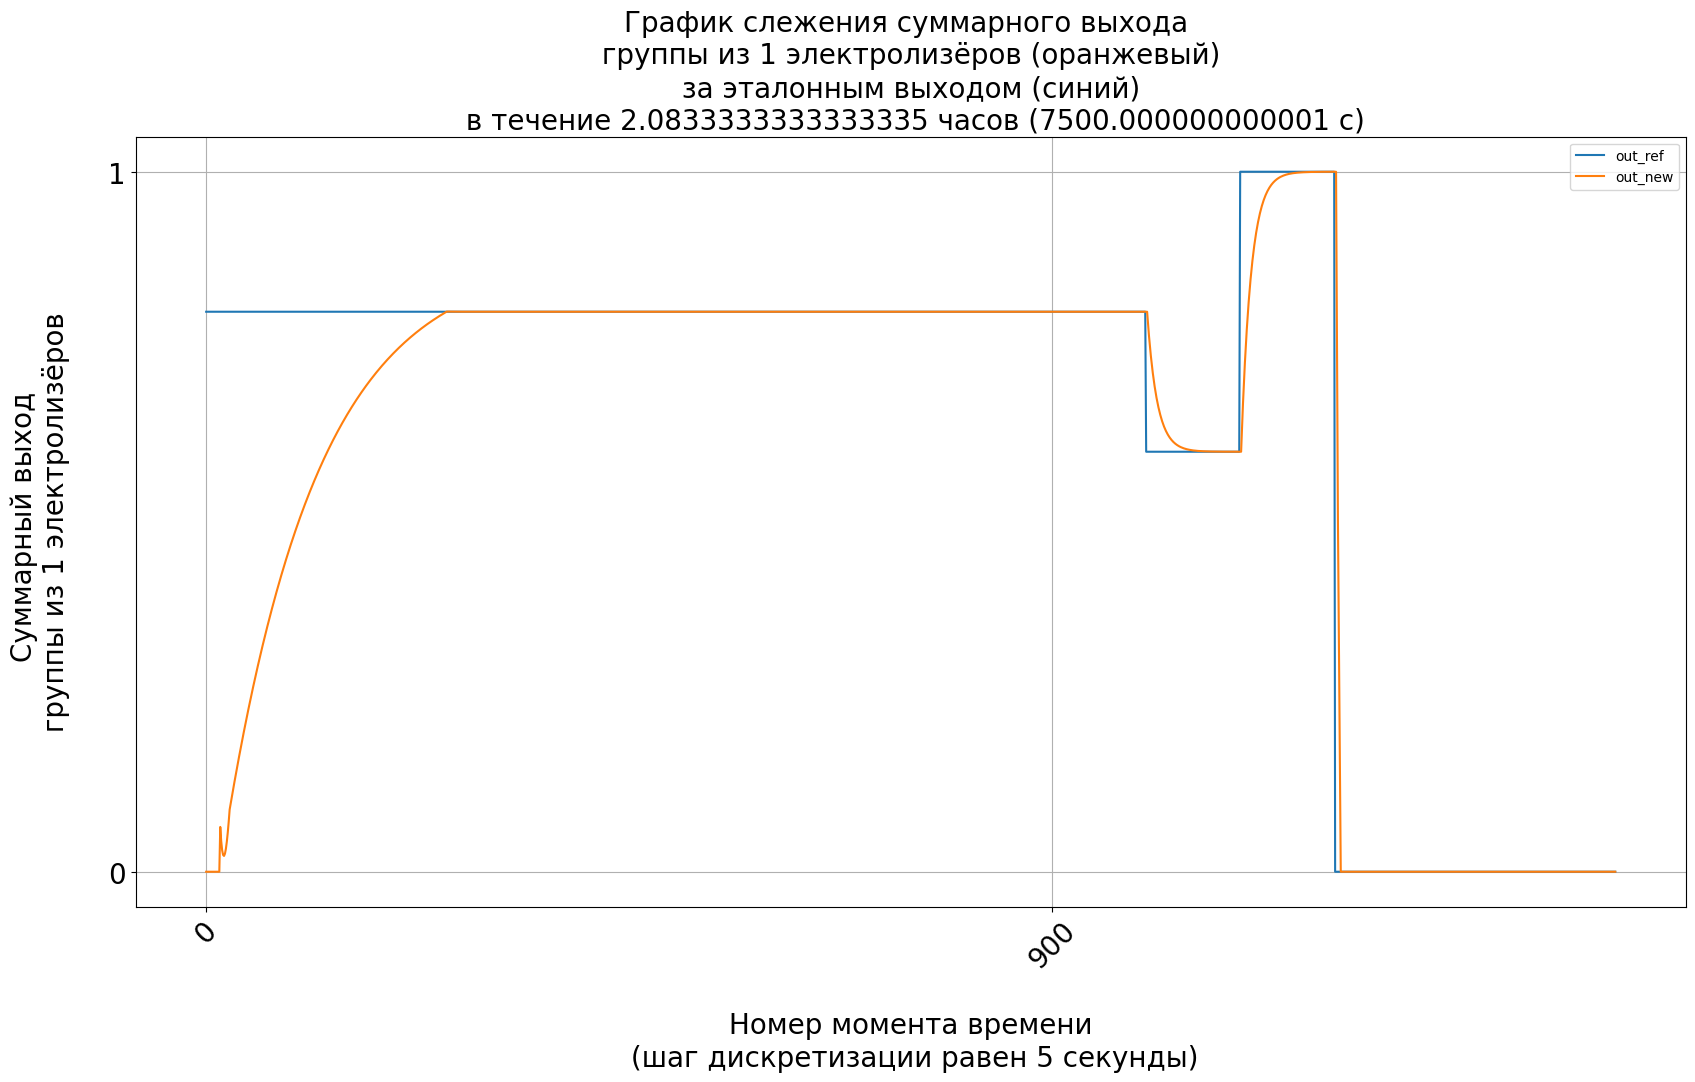

In [9]:
fig, ax = plt.subplots(figsize=(20, 10)) # (13, 6)
ax.set_title(f"График слежения суммарного выхода \n группы из {NUMBER_OF_ELECTROLYSERS} электролизёров (оранжевый) \n за эталонным выходом (синий) \n в течение {HOURS_IN_SIMULATION} часов ({HOURS_IN_SIMULATION * HOUR_TO_SEC} с)", fontsize=20)
plt.plot(out_ref, label='out_ref')
# plt.plot(out_old, label='out_old')
plt.plot(out_new, label='out_new')
# plt.plot(out_vec, label='out_vec')

# plt.plot(temp_old, label='out_old')
# plt.plot(temp_new, label='out_new')
# plt.plot(temp_vec, label='out_vec')

ax.set_xlabel(f'\n Номер момента времени \n (шаг дискретизации равен {SAMPLING_TIME} секунды)', fontsize=20)
ax.set_ylabel(f'Суммарный выход \n группы из {NUMBER_OF_ELECTROLYSERS} электролизёров \n', fontsize=20)
plt.legend()
plt.grid(visible=True)
#  Устанавливаем интервал основных делений:
ax.xaxis.set_major_locator(ticker.MultipleLocator(15 * 60))
#  Устанавливаем интервал вспомогательных делений:
#ax.xaxis.set_minor_locator(ticker.MultipleLocator(1))
#  Тоже самое проделываем с делениями на оси "y":
ax.yaxis.set_major_locator(ticker.MultipleLocator(1))
# ax.yaxis.set_minor_locator(ticker.MultipleLocator(10))
#  Настраиваем вид основных тиков:
ax.tick_params(axis = 'x', labelrotation = 45) # axis = 'both',
ax.tick_params(axis = 'both', labelsize = 20)
plt.show()

In [10]:
from plant_model import GroupOfElectrolysers

In [11]:
plant_model = GroupOfElectrolysers(5, 2)

In [12]:
group_deterioration = None
u = 0.8
U = np.ones(5)

In [13]:
Y = []

In [14]:
for k in range(1500):
    if k < 50:
        u = 0
    elif 50 <= k < 1000:
        u = 0.8
    elif 1000 <= k < 1200:
        u = 0.6
    elif 1200 <= k < 1500:
        u = 0
    [group_output,
     set_points,
     outputs,
     output_derives,
     temperatures,
     stack_states,
     group_deterioration_] = plant_model.group_state
    Y.append(group_output)
    group_deterioration = group_deterioration_
    plant_model.make_dynamical_step(u * U)


In [15]:
group_deterioration_

[2.0, 2.0, 2.0, 2.0, 2.0]

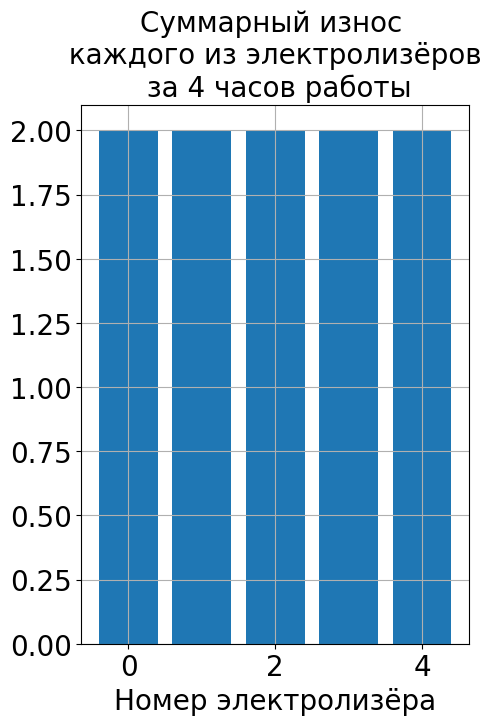

In [16]:
names = list(range(5))
fig, ax = plt.subplots(figsize=(5, 7))
ax.set_title(f"Суммарный износ \n каждого из электролизёров \n за {4} часов работы", fontsize=20)
plt.bar(names, group_deterioration)  # run_out_of_elecs
# plt.bar(names, num_of_switches_neural) # run_out_of_elecs
ax.set_xlabel('Номер электролизёра', fontsize=20)
plt.grid(visible=True)
ax.tick_params(axis='x', labelrotation=0)  # axis = 'both',
ax.tick_params(axis='both', labelsize=20)
plt.show()

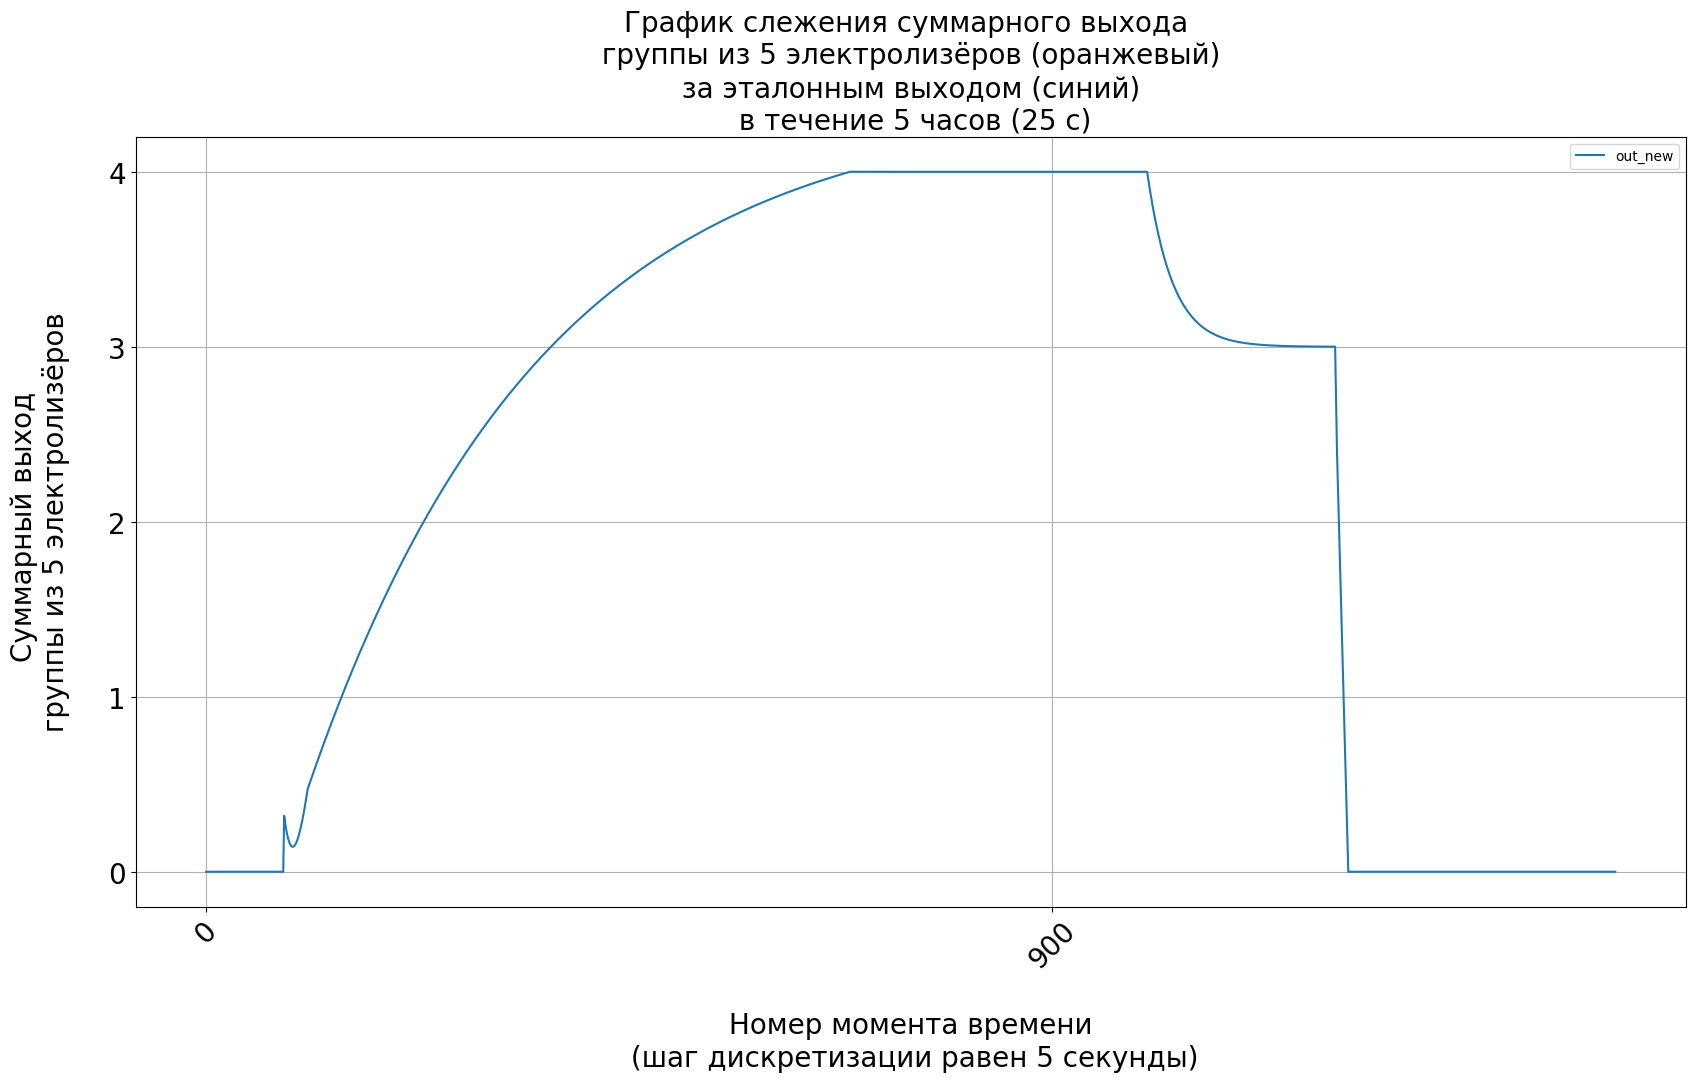

In [17]:
fig, ax = plt.subplots(figsize=(20, 10)) # 5
ax.set_title(f"График слежения суммарного выхода \n группы из {5} электролизёров (оранжевый) \n за эталонным выходом (синий) \n в течение {5} часов ({5 * 5} с)", fontsize=20)
# plt.plot(out_ref, label='out_ref')
# plt.plot(out_old, label='out_old')
plt.plot(Y, label='out_new')
# plt.plot(out_vec, label='out_vec')

# plt.plot(temp_old, label='out_old')
# plt.plot(temp_new, label='out_new')
# plt.plot(temp_vec, label='out_vec')

ax.set_xlabel(f'\n Номер момента времени \n (шаг дискретизации равен {5} секунды)', fontsize=20)
ax.set_ylabel(f'Суммарный выход \n группы из {5} электролизёров \n', fontsize=20)
plt.legend()
plt.grid(visible=True)
#  Устанавливаем интервал основных делений:
ax.xaxis.set_major_locator(ticker.MultipleLocator(15 * 60))
#  Устанавливаем интервал вспомогательных делений:
#ax.xaxis.set_minor_locator(ticker.MultipleLocator(1))
#  Тоже самое проделываем с делениями на оси "y":
ax.yaxis.set_major_locator(ticker.MultipleLocator(1))
# ax.yaxis.set_minor_locator(ticker.MultipleLocator(10))
#  Настраиваем вид основных тиков:
ax.tick_params(axis = 'x', labelrotation = 45) # axis = 'both',
ax.tick_params(axis = 'both', labelsize = 20)
plt.show()